In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [2]:
data=load_breast_cancer()
X=data.data
y=data.target
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [4]:
pca=PCA(n_components=2)
X_reduced=pca.fit_transform(X_scaled)

print("Original Shape:",X.shape)
print("Reduced Shape:",X_reduced.shape)

Original Shape: (569, 30)
Reduced Shape: (569, 2)


In [5]:
explained_variance=pca.explained_variance_ratio_
print(f"Explained Variance Ratio:",explained_variance)

Explained Variance Ratio: [0.44272026 0.18971182]


In [6]:
variance_retained=np.sum(explained_variance)
print(f"Total Variance Retained: {variance_retained}")

Total Variance Retained: 0.6324320765155946


In [7]:
information_loss=1-variance_retained
print(f"Info loss: {information_loss}")

Info loss: 0.36756792348440537


In [8]:
variance_retained+information_loss

1.0

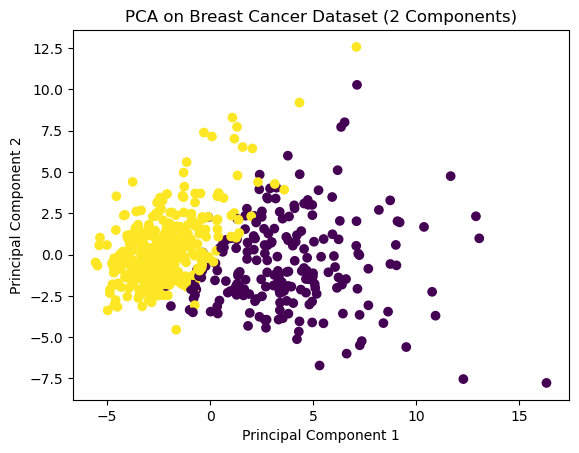

In [9]:
plt.figure()
plt.scatter(X_reduced[:,0],X_reduced[:,1],c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Breast Cancer Dataset (2 Components)")
plt.savefig("PCA on Breast Cancer Dataset (2 Components).png",dpi=100)
plt.show()